MAE: 5.004214037191819
MSE: 44.145298229382206
R2 Score: 0.8539627911457247


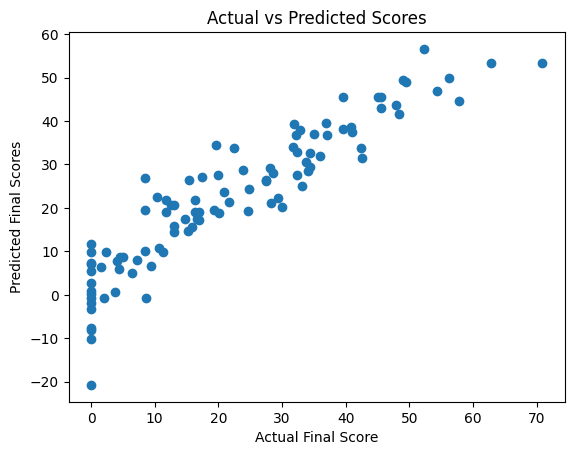

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)

n = 500  # bigger dataset

df = pd.DataFrame({
    "Age": np.random.randint(15, 20, n),
    "StudyTime": np.random.randint(1, 12, n),
    "Absences": np.random.randint(0, 30, n),
    "SleepHours": np.random.randint(4, 10, n),
    "StressLevel": np.random.randint(1, 10, n),
    "InternetAccess": np.random.choice(["Yes", "No"], n),
    "Gender": np.random.choice(["Male", "Female"], n),
    "ParentalEducation": np.random.choice(
        ["HighSchool", "Bachelor", "Master", "PhD"], n
    ),
    "Tutoring": np.random.choice(["Yes", "No"], n),
    "Extracurricular": np.random.choice(["Yes", "No"], n),
})

# REALISTIC SCORE GENERATION (important for patterns)
df["FinalScore"] = (
    df["StudyTime"] * 5
    - df["Absences"] * 1.2
    - df["StressLevel"] * 1.5
    + df["SleepHours"] * 2
    + np.where(df["InternetAccess"] == "Yes", 3, -2)
    + np.where(df["Tutoring"] == "Yes", 5, 0)
    + np.random.normal(0, 6, n)
)

df["FinalScore"] = df["FinalScore"].clip(0, 100)
# Saving the dataset
df.to_csv("student_perfomance.csv", index = False)


# Understanding the data
df.info()
df.describe()
df.isna().sum()
# Final Score Distribution Histogram
plt.hist(df["FinalScore"])
plt.title("Final Score Distribution")
plt.xlabel("Final Score Range")
plt.ylabel("Number of Students")   #--> Frequency
plt.show()
# Study Time Distribution Histogram
plt.hist(df["StudyTime"])
plt.title("Study Time Distribution")
plt.ylabel("Number of Students")
plt.xlabel("Study Time Range")
plt.show()
# Stress Level Distribution Histogram
plt.hist(df["StressLevel"])
plt.title("Stress Level Distribution")
plt.ylabel("Number of Students")
plt.xlabel("Stress Level Distribution")
plt.show()
# Final Score Comparision between people with and without Intenet Access
sns.boxplot(x = "InternetAccess", y = "FinalScore", data = df)
plt.title("Internet Acess vs Final Score")
plt.show()
# Final Score Comparision between people with and without Tutoring
sns.boxplot(x = "Tutoring", y = "FinalScore", data = df)
plt.title("Tutoring vs Final Score")
plt.show()
# Final Score Comparision between people with and without Parental Education
sns.boxplot(x = "ParentalEducation", y = "FinalScore", data = df)
plt.xticks(rotation = 45)
plt.show()
# Direct comparision between Study and Final Score
plt.scatter(df["StudyTime"], df["FinalScore"])
plt.xlabel("Study Time")
plt.ylabel("Final Score")
plt.title("Study Time vs Final Score")
plt.show()
# Absences vs Score
plt.scatter(df["Absences"], df["FinalScore"])
plt.title("Absences vs Final Score")
plt.show()
# Stress vs Score
plt.scatter(df["StressLevel"], df["FinalScore"])
plt.title("Stress vs Final Score")
plt.show()
# Outliers
sns.boxplot(x = df["FinalScore"])
plt.title("Final Score Outliers")
plt.show()
# Tutorial Effect
df.groupby("Tutoring")[" FinalScore"].mean()
# Internet Effect
df.groupby("InternetAccess")["FinalScore"].mean()
# Parental Education Effect
df.groupby("ParentalEducation")["FinalScore"].mean()

# Which variables influence FinalScore the most
df.corr(numeric_only = True)["FinalScore"].sort_values(ascending = False)

#StudyTime vs FinalScore
plt.scatter(df["StudyTime"], df["FinalScore"])
plt.xlabel("StudyTime")
plt.ylabel("FinalScore")
plt.title("Study Time  vs Final Score")
plt.show()
# Insight: StudyTime shows a positive relationship with FinalScore, with noticeable variation due to added randomness.

#Absense vs FinalScore
plt.scatter(df["Absences"], df["FinalScore"])
plt.xlabel("Absences")
plt.ylabel("Final Score")
plt.title("Absences vs Final Score")
plt.show()
# Insight: Absences show a negative relationship with FinalScore, indicating that higher absenteeism reduces performance in this dataset.

# StudyTime and Absences VS FinalScore
plt.scatter(df["StudyTime"], df["Absences"], c = df["FinalScore"], cmap = "viridis")
plt.xlabel("StudyTime")
plt.ylabel("Absences")
plt.title("StudyTime vs Absences (colored by FinalScore)")
plt.colorbar(label = "FinalScore")
plt.show()
# Insight: FinalScore is highest when StudyTime is high and Absences are low, showing that combined behaviour of features gives a stronger prediction.


X = df.drop("FinalScore", axis = 1)
y = df["FinalScore"]
# Handling categorial variables
X["InternetAccess"] = X["InternetAccess"].map({"Yes": 1, "No": 0})
X["Gender"] = X["Gender"].map({"Female": 1, "Male": 0})
X["Tutoring"] = X["Tutoring"].map({"Yes": 1, "No": 0})
X["Extracurricular"] = X["Extracurricular"].map({"Yes": 1, "No": 0})
X["ParentalEducation"] = X["ParentalEducation"].map({"HighSchool": 1, "Bachelor": 2, "Master": 3, "PhD": 4})
# Full the null values
X.isna().sum()
X = X.fillna(X.mean())

# Train-test split (80/20)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

# Training the model using Linear Regression
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)
# Making prediction
y_pred = model.predict(X_test)
print(y_pred[:10])
print(y_test[:10].values)

# Model Evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)
# MSE - for severity of mistakes
mse = mean_squared_error(y_test, y_pred)
print("MSE:", mse)
# Shows accuracy on a scale of 1.0
r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

# Creating a comparision table
comparision = pd.DataFrame({
    "Actual": y_test, "Predicted": y_pred
})
comparision.head(20)
# Error calculation
comparision["Error"] = comparision["Actual"] - comparision["Predicted"]
comparision.head(20)
# Find biggest mistakes
comparision.sort_values(by = "Error", key = abs, ascending = False).head(10)
# Find smallest mistakes
comparision.sort_values(by = "Error", key = abs, ascending = True).head(10)
# Check whether the model overestimates or underestimates more often
(comparision["Error"] < 0).sum()
(comparision["Error"] > 0).sum()
comparision["Error"].mean()

# Difference between predictions and reality
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Final Score")
plt.ylabel("Predicted Final Scores")
plt.title("Actual vs Predicted Scores")
plt.show()